In [10]:
import pandas as pd
import numpy as np

players_fresh_final = pd.read_csv('../data/players_fresh_final.csv')
players_fresh_final['log_value'] = np.log1p(players_fresh_final['current_value'])

In [11]:
from sklearn.model_selection import train_test_split

X = players_fresh_final.drop(columns=['current_value', 'log_value'])
y = players_fresh_final['log_value']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Train: {len(X_train)} samples, Test: {len(X_test)} samples")

Train: 3852 samples, Test: 964 samples


In [12]:
from sklearn.metrics import mean_squared_error, r2_score

mean_pred = np.full_like(y_test, y_train.mean())
mean_mse = mean_squared_error(y_test, mean_pred)
mean_r2 = r2_score(y_test, mean_pred)
print(f"Mean model - MSE: {mean_mse:.3f}, R2: {mean_r2:.3f}")

Mean model - MSE: 2.843, R2: -0.000


In [13]:
median_pred = np.full_like(y_test, y_train.median())
median_mse = mean_squared_error(y_test, median_pred)
median_r2 = r2_score(y_test, median_pred)
print(f"Median model - MSE: {median_mse:.3f}, R2: {median_r2:.3f}")

Median model - MSE: 2.854, R2: -0.004


In [14]:
from sklearn.linear_model import LinearRegression

age_model = LinearRegression()
age_model.fit(X_train[['age']], y_train)
age_pred = age_model.predict(X_test[['age']])
age_mse = mean_squared_error(y_test, age_pred)
age_r2 = r2_score(y_test, age_pred)
print(f"Age model - MSE: {age_mse:.3f}, R2: {age_r2:.3f}")

Age model - MSE: 2.562, R2: 0.099


In [15]:
minutes_model = LinearRegression()
minutes_model.fit(X_train[['total_minutes']], y_train)
minutes_pred = minutes_model.predict(X_test[['total_minutes']])
minutes_mse = mean_squared_error(y_test, minutes_pred)
minutes_r2 = r2_score(y_test, minutes_pred)
print(f"Minutes model - MSE: {minutes_mse:.3f}, R2: {minutes_r2:.3f}")

Minutes model - MSE: 2.688, R2: 0.054


In [16]:
results = pd.DataFrame({
    'Model': ['Mean baseline', 'Median baseline', 'Age-only', 'Minutes-only'],
    'RMSE': [np.sqrt(mean_mse), np.sqrt(median_mse), np.sqrt(age_mse), np.sqrt(minutes_mse)],
    'R2': [mean_r2, median_r2, age_r2, minutes_r2]
})
print(results)
print(X_train.isna().sum())
print(X_train.dtypes)

             Model      RMSE        R2
0    Mean baseline  1.686223 -0.000376
1  Median baseline  1.689382 -0.004128
2         Age-only  1.600486  0.098767
3     Minutes-only  1.639661  0.054108
player_id                 0
name                      0
current_date              0
peak_value                0
peak_date                 0
days_since_update         0
is_stale                  0
total_goals               0
total_assists             0
total_minutes             0
total_appearances         0
total_yellow_cards        0
total_red_cards           0
goals_per_90              0
assists_per_90            0
date_of_birth             0
position                  0
sub_position              0
foot                      0
height_in_cm              0
country_of_citizenship    0
age                       0
dtype: int64
player_id                   int64
name                          str
current_date                  str
peak_value                  int64
peak_date                     str
days_s

In [17]:
appearances = pd.read_csv("../data/appearances.csv")
games = pd.read_csv("../data/games.csv")
competitions = pd.read_csv("../data/competitions.csv")

appearances["date"] = pd.to_datetime(appearances['date'])
players_fresh_final['current_date'] = pd.to_datetime(players_fresh_final['current_date'])

games_competitions = games.merge(competitions[['competition_id', 'name']], on="competition_id", how="left").rename(columns={"name": "competition_name"})
appearances_games = appearances.merge(games_competitions[['game_id', 'competition_name']], on="game_id", how="left")
apps = appearances_games.merge(players_fresh_final[['player_id', 'current_date']], on="player_id", how="inner")

apps = apps[apps['date'] <= apps['current_date']].copy()
apps_recent = apps[apps['date'] >= (apps['current_date'] - pd.Timedelta(days=365))].copy()

T1 = {'Premier League', 'La Liga', 'Serie A', 'Bundesliga', 'Ligue 1'}
T2 = {'Championship', 'Eredivisie', 'Primeira Liga', 'Süper Lig'}

def get_tier(name):
    if pd.isna(name):
        return np.nan
    s = str(name).lower()

    tier1_keys = [
        "premier league", "la liga", "laliga", "serie a", "bundesliga", "ligue 1"
    ]
    tier2_keys = [
        "championship", "eredivisie", "primeira liga", "süper lig", "super lig", "jupiler", "belgian pro league"
    ]

    if any(k in s for k in tier1_keys):
        return 3
    if any(k in s for k in tier2_keys):
        return 2
    return 1

apps_recent['league_tier'] = apps_recent['competition_name'].map(get_tier)

recent_stats = apps_recent.groupby('player_id').agg(
    recent_goals=('goals', 'sum'),
    recent_assists=('assists', 'sum'),
    recent_minutes=('minutes_played', 'sum'),
    recent_appearances=('game_id', 'count'),
    league_tier=('league_tier', 'median'),
).reset_index()

recent_stats['recent_goals_per_90'] = np.where(recent_stats['recent_minutes'] > 0, recent_stats['recent_goals']*90/recent_stats['recent_minutes'], 0)
recent_stats['recent_assists_per_90'] = np.where(recent_stats['recent_minutes'] > 0, recent_stats['recent_assists']*90/recent_stats['recent_minutes'], 0)
players_fresh_final['age_squared'] = players_fresh_final['age'] ** 2
players_fresh_final2 = players_fresh_final.merge(recent_stats[['player_id', 'recent_goals_per_90', 'recent_assists_per_90', 'recent_minutes', 'league_tier']], on='player_id', how='left')

players_fresh_final2['recent_goals_per_90'] = players_fresh_final2['recent_goals_per_90'].fillna(0)
players_fresh_final2['recent_assists_per_90'] = players_fresh_final2['recent_assists_per_90'].fillna(0)
players_fresh_final2['recent_minutes'] = players_fresh_final2['recent_minutes'].fillna(0)
players_fresh_final2['league_tier_missing'] = players_fresh_final2['league_tier'].isna().astype(int)
players_fresh_final2['league_tier'] = players_fresh_final2['league_tier'].fillna(1)

features = ['age', 'age_squared', 'total_minutes', 'recent_goals_per_90', 'recent_assists_per_90', 'recent_minutes', 'league_tier', 'league_tier_missing', 'position']
X2_full = players_fresh_final2[features]
y2_full = players_fresh_final2['log_value']

X2_full = pd.get_dummies(X2_full, columns=['position'], drop_first=True)
print(X2_full.columns.tolist())
X2_train_full, X2_test, y2_train_full, y2_test = train_test_split(X2_full, y2_full, test_size=0.2, random_state=42)

['age', 'age_squared', 'total_minutes', 'recent_goals_per_90', 'recent_assists_per_90', 'recent_minutes', 'league_tier', 'league_tier_missing', 'position_Defender', 'position_Goalkeeper', 'position_Midfield']


In [18]:
print("competition_name sample:")
print(apps_recent['competition_name'].dropna().value_counts().head(20))

print("\nleague_tier distribution in apps_recent:")
print(apps_recent['league_tier'].value_counts(dropna=False))

print("\nleague_tier distribution in players_fresh_final2:")
print(players_fresh_final2['league_tier'].value_counts(dropna=False))

print("\nleague_tier nunique:", players_fresh_final2['league_tier'].nunique())

competition_name sample:
competition_name
premier-liga                         9835
premier-league                       9713
bundesliga                           7900
serie-a                              7484
liga-portugal                        6900
super-lig                            6173
laliga                               6153
ligue-1                              5922
eredivisie                           5920
jupiler-pro-league                   4291
uefa-champions-league                4039
scottish-premiership                 3717
super-league-1                       3604
superliga                            3084
uefa-europa-league                   2862
russian-cup                          1021
uefa-conference-league-qualifying     972
fa-cup                                872
kypello-elladas                       770
dfb-pokal                             669
Name: count, dtype: int64

league_tier distribution in apps_recent:
league_tier
1.0    72245
3.0    14053
2.0    10211

In [19]:
players_fresh_final['age_squared'] = players_fresh_final['age'] ** 2

feature_cols = ['age', 'age_squared', 'goals_per_90', 'assists_per_90', 'total_minutes', 'position']
X_full = players_fresh_final[feature_cols]
y_full = players_fresh_final['log_value']

In [20]:
X_full = pd.get_dummies(X_full, columns=['position'], drop_first=True)
print(X_full.columns.tolist()) #position_atack is a base position, so it is dropped to avoid multicollinearity
X_train_full, X_test_full, y_train_full, y_test_full = train_test_split(X_full, y_full, test_size=0.2, random_state=42)

['age', 'age_squared', 'goals_per_90', 'assists_per_90', 'total_minutes', 'position_Defender', 'position_Goalkeeper', 'position_Midfield']


In [21]:
linear_model = LinearRegression()
linear_model.fit(X_train_full, y_train_full)
linear_pred = linear_model.predict(X_test_full)

linear_mse = mean_squared_error(y_test_full, linear_pred)
linear_r2 = r2_score(y_test_full, linear_pred)
print(f"Linear Regression model - RMSE: {np.sqrt(linear_mse):.3f}, R2: {linear_r2:.3f}")

Linear Regression model - RMSE: 1.206, R2: 0.488


In [22]:
linear_model2 = LinearRegression()
linear_model2.fit(X2_train_full, y2_train_full)
linear_pred2 = linear_model2.predict(X2_test)

linear_mse2 = mean_squared_error(y2_test, linear_pred2)
linear_r2_2 = r2_score(y2_test, linear_pred2)
print(f"Linear Regression model with recent stats - RMSE: {np.sqrt(linear_mse2):.3f}, R2: {linear_r2_2:.3f}")


Linear Regression model with recent stats - RMSE: 1.063, R2: 0.602


In [23]:
from sklearn.linear_model import Lasso, Ridge

lasso_model = Lasso(alpha=0.01, random_state=42)
lasso_model.fit(X_train_full, y_train_full)
lasso_pred = lasso_model.predict(X_test_full)
lasso_rmse = np.sqrt(mean_squared_error(y_test_full, lasso_pred))
lasso_r2 = r2_score(y_test_full, lasso_pred)
print(f"Lasso — RMSE: {lasso_rmse:.3f}, R2: {lasso_r2:.3f}")#lasso can nullify some coefficients, which can be useful for feature selection

ridge_model = Ridge(alpha=1.0, random_state=42)
ridge_model.fit(X_train_full, y_train_full)
ridge_pred = ridge_model.predict(X_test_full)
ridge_rmse = np.sqrt(mean_squared_error(y_test_full, ridge_pred))
ridge_r2 = r2_score(y_test_full, ridge_pred)
print(f"Ridge — RMSE: {ridge_rmse:.3f}, R2: {ridge_r2:.3f}")#ridge can help with multicollinearity by adding a penalty to the size of the coefficients(reduce but not nullify them)

Lasso — RMSE: 1.217, R2: 0.479
Ridge — RMSE: 1.206, R2: 0.489


In [24]:
lasso_model2 = Lasso(alpha=0.01, random_state=42)
lasso_model2.fit(X2_train_full, y2_train_full)
lasso_pred2 = lasso_model2.predict(X2_test)
lasso_mse2 = mean_squared_error(y2_test, lasso_pred2)
lasso_r2_2 = r2_score(y2_test, lasso_pred2)
print(f"Lasso with recent stats — RMSE: {np.sqrt(lasso_mse2):.3f}, R2: {lasso_r2_2:.3f}")

ridge_model2 = Ridge(alpha=1.0, random_state=42)
ridge_model2.fit(X2_train_full, y2_train_full)
ridge_pred2 = ridge_model2.predict(X2_test)
ridge_mse2 = mean_squared_error(y2_test, ridge_pred2)
ridge_r2_2 = r2_score(y2_test, ridge_pred2)
print(f"Ridge with recent stats — RMSE: {np.sqrt(ridge_mse2):.3f}, R2: {ridge_r2_2:.3f}")

Lasso with recent stats — RMSE: 1.064, R2: 0.601
Ridge with recent stats — RMSE: 1.063, R2: 0.602


Random Forest model, with cross-validation

In [25]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score

rf_model = RandomForestRegressor(n_estimators=200, random_state=42)
rf_model.fit(X_train_full, y_train_full)
rf_pred = rf_model.predict(X_test_full)

rf_rmse = np.sqrt(mean_squared_error(y_test_full, rf_pred))
rf_r2 = r2_score(y_test_full, rf_pred)
print(f"Random Forest — RMSE: {rf_rmse:.3f}, R2: {rf_r2:.3f}")


Random Forest — RMSE: 1.106, R2: 0.569


In [26]:
rf_model2 = RandomForestRegressor(n_estimators=200, random_state=42)
rf_model2.fit(X2_train_full, y2_train_full)
rf_pred2 = rf_model2.predict(X2_test)
rf_mse2 = mean_squared_error(y2_test, rf_pred2)
rf_r2_2 = r2_score(y2_test, rf_pred2)
print(f"Random Forest with recent stats — RMSE: {np.sqrt(rf_mse2):.3f}, R2: {rf_r2_2:.3f}")
cs_scores_2 = cross_val_score(rf_model2, X2_train_full, y2_train_full, cv=5, scoring='r2')
print(f"Cross-validated R2 scores for Random Forest with recent stats: {cs_scores_2}")
print(f"Random Forest mean cross-validated R2 score for Random Forest with recent stats: {cs_scores_2.mean():.3f}, std: {cs_scores_2.std():.3f}")

Random Forest with recent stats — RMSE: 1.006, R2: 0.644
Cross-validated R2 scores for Random Forest with recent stats: [0.58034457 0.59665461 0.58571695 0.65678844 0.55235652]
Random Forest mean cross-validated R2 score for Random Forest with recent stats: 0.594, std: 0.034


In [27]:
cs_scores = cross_val_score(rf_model, X_full, y_full, cv=5, scoring='r2')
print(f"Random Forest cross-validated R2 scores: {cs_scores}")
print(f"Random Forest mean cross-validated R2 score: {cs_scores.mean():.3f}, std: {cs_scores.std():.3f}")

Random Forest cross-validated R2 scores: [0.57453976 0.4682457  0.46437673 0.42042763 0.55003958]
Random Forest mean cross-validated R2 score: 0.496, std: 0.058


In [28]:
#feature importance
importances = pd.Series(rf_model.feature_importances_, index=X_train_full.columns)
print(importances.sort_values(ascending=False))

total_minutes          0.397883
age_squared            0.197194
age                    0.190070
goals_per_90           0.097152
assists_per_90         0.094557
position_Midfield      0.010256
position_Defender      0.009224
position_Goalkeeper    0.003664
dtype: float64


In [29]:
importances2 = pd.Series(rf_model2.feature_importances_, index=X2_train_full.columns)
print(importances2.sort_values(ascending=False))

recent_minutes           0.404589
total_minutes            0.168054
age                      0.136639
age_squared              0.132625
recent_goals_per_90      0.065572
recent_assists_per_90    0.044913
league_tier              0.026326
position_Defender        0.007736
position_Midfield        0.007647
position_Goalkeeper      0.004187
league_tier_missing      0.001714
dtype: float64


In [30]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_leaf': [1, 2, 4]
}

rf_search = RandomizedSearchCV(RandomForestRegressor(random_state=42), param_dist, cv=5, scoring='r2', n_iter=10, random_state=42, n_jobs=-1)
rf_search.fit(X_train_full, y_train_full)
print(f"Best params: {rf_search.best_params_}")

rf_best = rf_search.best_estimator_
rf_best_pred = rf_best.predict(X_test_full)
rf_best_rmse = np.sqrt(mean_squared_error(y_test_full, rf_best_pred))
rf_best_r2 = r2_score(y_test_full, rf_best_pred)
print(f"Tuned Random Forest — RMSE: {rf_best_rmse:.3f}, R2: {rf_best_r2:.3f}")

Best params: {'n_estimators': 300, 'min_samples_leaf': 4, 'max_depth': 10}
Tuned Random Forest — RMSE: 1.080, R2: 0.590


In [31]:
rf_search2 = RandomizedSearchCV(RandomForestRegressor(random_state=42), param_dist, cv=5, scoring='r2', n_iter=10, random_state=42, n_jobs=-1)
rf_search2.fit(X2_train_full, y2_train_full)
print(f"Best params for Random Forest with recent stats: {rf_search2.best_params_}")

rf_best2 = rf_search2.best_estimator_
rf_best_pred2 = rf_best2.predict(X2_test)
rf_best_rmse2 = np.sqrt(mean_squared_error(y2_test, rf_best_pred2))
rf_best_r2_2 = r2_score(y2_test, rf_best_pred2)
print(f"Tuned Random Forest with recent stats — RMSE: {rf_best_rmse2:.3f}, R2: {rf_best_r2_2:.3f}")

Best params for Random Forest with recent stats: {'n_estimators': 300, 'min_samples_leaf': 4, 'max_depth': 10}
Tuned Random Forest with recent stats — RMSE: 0.983, R2: 0.660


In [32]:
#final table of results

results = pd.DataFrame({
    'Model': ['Mean baseline', 'Median baseline', 'Age-only', 'Minutes-only', 'Linear Regression', 'Lasso', 'Ridge', 'Random Forest', 'Tuned Random Forest'],
    'RMSE': [np.sqrt(mean_mse), np.sqrt(median_mse), np.sqrt(age_mse), np.sqrt(minutes_mse), np.sqrt(linear_mse), lasso_rmse, ridge_rmse, rf_rmse, rf_best_rmse],
    'R2': [mean_r2, median_r2, age_r2, minutes_r2, linear_r2, lasso_r2, ridge_r2, rf_r2, rf_best_r2]
}) 
print(results)
compare_results = results.sort_values(by='R2', ascending=False)
print(compare_results)

                 Model      RMSE        R2
0        Mean baseline  1.686223 -0.000376
1      Median baseline  1.689382 -0.004128
2             Age-only  1.600486  0.098767
3         Minutes-only  1.639661  0.054108
4    Linear Regression  1.205788  0.488465
5                Lasso  1.217281  0.478668
6                Ridge  1.205532  0.488682
7        Random Forest  1.106209  0.569466
8  Tuned Random Forest  1.079582  0.589943
                 Model      RMSE        R2
8  Tuned Random Forest  1.079582  0.589943
7        Random Forest  1.106209  0.569466
6                Ridge  1.205532  0.488682
4    Linear Regression  1.205788  0.488465
5                Lasso  1.217281  0.478668
2             Age-only  1.600486  0.098767
3         Minutes-only  1.639661  0.054108
0        Mean baseline  1.686223 -0.000376
1      Median baseline  1.689382 -0.004128


In [33]:
results2 = pd.DataFrame({
    'Model': ['Mean baseline', 'Median baseline', 'Age-only', 'Minutes-only', 'Linear Regression with recent stats', 'Lasso with recent stats', 'Ridge with recent stats', 'Random Forest with recent stats', 'Tuned Random Forest with recent stats'],
    'RMSE': [np.sqrt(mean_mse), np.sqrt(median_mse), np.sqrt(age_mse), np.sqrt(minutes_mse), np.sqrt(linear_mse2), np.sqrt(lasso_mse2), np.sqrt(ridge_mse2), np.sqrt(rf_mse2), rf_best_rmse2],
    'R2': [mean_r2, median_r2, age_r2, minutes_r2, linear_r2_2, lasso_r2_2, ridge_r2_2, rf_r2_2, rf_best_r2_2]
}) 
print(results2)
compare_results2 = results2.sort_values(by='R2', ascending=False)
print(compare_results2)

                                   Model      RMSE        R2
0                          Mean baseline  1.686223 -0.000376
1                        Median baseline  1.689382 -0.004128
2                               Age-only  1.600486  0.098767
3                           Minutes-only  1.639661  0.054108
4    Linear Regression with recent stats  1.063048  0.602407
5                Lasso with recent stats  1.064313  0.601460
6                Ridge with recent stats  1.063066  0.602394
7        Random Forest with recent stats  1.005740  0.644119
8  Tuned Random Forest with recent stats  0.983205  0.659888
                                   Model      RMSE        R2
8  Tuned Random Forest with recent stats  0.983205  0.659888
7        Random Forest with recent stats  1.005740  0.644119
4    Linear Regression with recent stats  1.063048  0.602407
6                Ridge with recent stats  1.063066  0.602394
5                Lasso with recent stats  1.064313  0.601460
2                       

# Model comparison summary

Random Forest with recent stats is the best model (CV R2=0.657, RMSE=0.987).
Compared with the base model, recent stats improve both overall fit and top-end calibration.
Total_minutes is still dominant, but recent_minutes adds useful signal.
This matches what is in EDA, total_minutes dominates (0.454). Age and age_squared combined contribute 0.37 of importance, so earlier decision to include the non-linear age term is solid.

Position dummies contribute almost nothing (<0.01), matching the earlier observation that Attack/Defender/Midfield showed surprisingly similar value distributions in EDA.
goals_per_90 (0.082) and assists_per_90 (0.074) have less weight than total_minutes, so playing time may be a stronger value signal.

In [34]:
#rewriting all to the best model with recent stats


In [35]:
residuals = y_test_full - rf_best_pred
residual_df = players_fresh_final.loc[X_test_full.index, ['name', 'position', 'age', 'total_minutes']].copy()
residual_df['actual_log_value'] = y_test_full
residual_df['predicted_log_value'] = rf_best_pred
residual_df['residual'] = residuals

<Axes: >

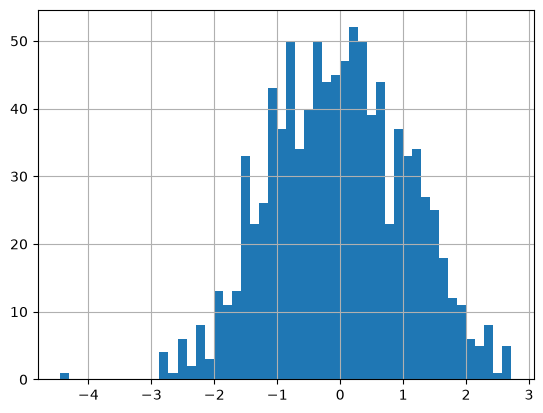

In [36]:
residual_df['residual'].hist(bins=50)

In [37]:
print("Most overvalued (actual >> predicted):")
print(residual_df.sort_values('residual', ascending=False).head(10))

print("Most undervalued (actual << predicted):")
print(residual_df.sort_values('residual').head(10))

Most overvalued (actual >> predicted):
                   name    position        age  total_minutes  \
3845        Kaishu Sano    Midfield  24.969199           4874   
4277      Ardon Jashari    Midfield  23.400411           3032   
1732       Andrei Rațiu    Defender  27.479808           6295   
1170  Caoimhín Kelleher  Goalkeeper  27.044490           6270   
4375    Niccolò Fortini    Defender  19.857632            447   
831     Antoine Semenyo      Attack  25.921971           7634   
3846      Aurèle Amenda    Defender  22.387406            487   
1047  Emiliano Martínez  Goalkeeper  33.267625          22436   
1149    Viktor Gyökeres      Attack  27.515400           8774   
1210     Matheus França    Midfield  21.691992            381   

      actual_log_value  predicted_log_value  residual  
3845         17.034386            14.317787  2.716600  
4277         17.281246            14.608653  2.672594  
1732         16.705882            14.084944  2.620938  
1170         16.90655

# Error analysis

1. Most overvalued by actual value. Nearly all top overvalued players (e.g. Jay Robinson, Wisdom Mike, Vasilije Adžić) are very young (18-25) with low total_minutes. So when they carry high real market value, the model underpredicts them because it has almost no performance signal to work with. Their prices are driven by potential, reputation, hype and young age, none of which are captured as features here.

2. Veterans overvalued by the model (most undervalued by actual value). Nearly all top undervalued players (e.g. Stephen O'Donnell, Bruce Anderson) are old (25-33) with very high career minutes (up to 26,092), but low actual market value.Since total_minutes is the model's most important feature (0.454 importance), the model overvalue their playing time. But the real market has already discounted these players for age-related decline, an effect age_squared captures only partially at these extremes.

The limitation of the model from both patterns is that the model has no feature about reputation, potential or market hype. And underweights how strongly age discounts value for  veterans specifically.

<Axes: title={'center': 'residual'}, xlabel='position'>

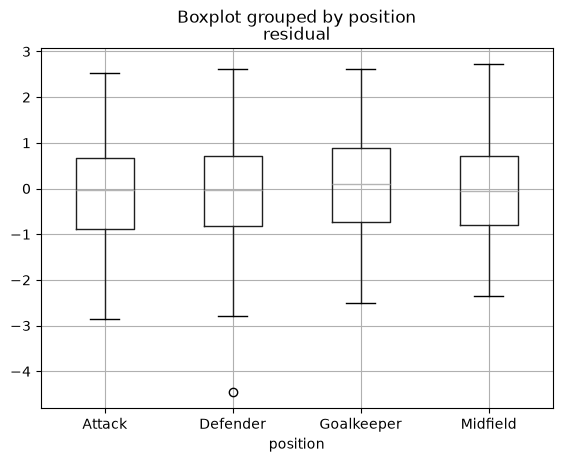

In [38]:
residual_df.boxplot(column='residual', by='position')

All 4 positions are centered close to 0. So there is no huge overall bias by position.
Goalkeeper boxplot is a bit higher(harder to predict, probably because goals_per_90/assists_per_90 mean almost nothing for keepers).
Attack and defender have a bit outliers(<-3), matching the same undervalued veterans found earlier

In [39]:
from scipy.stats import skew, kurtosis
import matplotlib.pyplot as plt
print(f"Residual skewness: {skew(residuals):.3f}")

Residual skewness: -0.043


Text(0, 0.5, 'Residual')

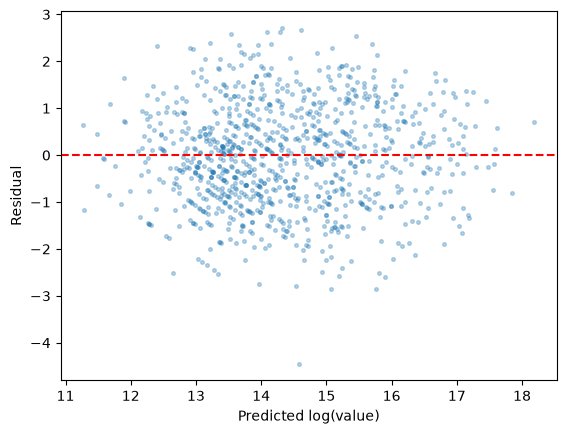

In [40]:
plt.scatter(rf_best_pred, residuals, alpha=0.3, s=7)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted log(value)')
plt.ylabel('Residual')

Residual distribution is almost symmetric (skewness 0.094 is close to 0). This indicates the models errors are unbiased and not skewed toward over- or under-prediction, a well-calibrated result.

In [41]:
import joblib
final_model = RandomForestRegressor(**rf_search.best_params_, random_state=42)
final_model.fit(X_full, y_full)

players_fresh_final['predicted_log_value'] = final_model.predict(X_full)
players_fresh_final['residual'] = players_fresh_final['log_value'] - players_fresh_final['predicted_log_value']

joblib.dump(final_model, '../app/model.pkl')
players_fresh_final.to_csv('../app/dashboard_data.csv', index=False)

In [42]:
dashboard_data = pd.read_csv("../app/dashboard_data.csv")

print("Most overvalued (actual >> predicted):")
print(dashboard_data.sort_values('residual', ascending=False).head(10))

print("Most undervalued (actual << predicted):")
print(dashboard_data.sort_values('residual').head(10))

Most overvalued (actual >> predicted):
      player_id             name  current_value current_date  peak_value  \
603      864121     Abdul Fatawu       20000000   2025-12-03    20000000   
564      665390  Jaden Philogene       18000000   2025-12-03    18000000   
547      596446       Leif Davis       20000000   2025-12-03    25000000   
1163     345911  Ladislav Krejci       22000000   2025-12-09    22000000   
611      747951     Shea Charles       12000000   2025-12-03    12000000   
591      693095    Jacob Greaves       16000000   2025-12-03    20000000   
604      696346   Jay Stansfield       18000000   2025-12-03    18000000   
571      506189     Flynn Downes       12000000   2025-12-03    15000000   
4379     668207      Petar Sučić       30000000   2025-12-23    30000000   
1732     527966     Andrei Rațiu       18000000   2025-12-12    18000000   

       peak_date  days_since_update  is_stale  total_goals  total_assists  \
603   2025-12-03                 86     False  

In [43]:
from sklearn.model_selection import cross_val_predict

best_rf = RandomForestRegressor(**rf_search.best_params_, random_state=42)
oof_predictions = cross_val_predict(best_rf, X_full, y_full, cv=5)

players_fresh_final['predicted_log_value'] = oof_predictions
players_fresh_final['residual'] = players_fresh_final['log_value'] - oof_predictions

print("Most undervalued (actual << predicted):")
print(players_fresh_final.sort_values('residual').head(10))

Most undervalued (actual << predicted):
      player_id               name  current_value current_date  peak_value  \
2264    1046648   Lukas Kirkegaard          25000   2025-12-15       25000   
54       418891   Oleksandr Melnyk          25000   2025-06-10      300000   
3914     935047      Kyrylo Sigeev         150000   2025-12-19      600000   
4627    1201294      Ozan Demirbağ         175000   2025-12-29      175000   
92       383198      Ilya Shevtsov          75000   2025-10-21      400000   
441      315211    Sherel Floranus         800000   2025-12-02     1000000   
1381     186337  Stephen O'Donnell          50000   2025-12-10      900000   
1538     382096     Bruce Anderson         300000   2025-12-10      600000   
3256     717413    Oleg Pushkaryov         200000   2025-12-18      300000   
3122     726038      Vitaliy Roman         500000   2025-12-18      800000   

       peak_date  days_since_update  is_stale  total_goals  total_assists  \
2264  2025-09-02        

In [44]:
final_model = RandomForestRegressor(**rf_search.best_params_, random_state=42)
final_model.fit(X_full, y_full)
joblib.dump(final_model, '../app/model.pkl')

players_fresh_final.to_csv('../app/dashboard_data.csv', index=False)

Initially the model was trained on 100% of data, and used its own predictions for analysis, but this produced predictions where the model had already seen each player's true value during training. Fixed by using cross_val_predict to generate honest predictions for every player.

In [45]:
print(dashboard_data.loc[[2564, 82, 2631, 4470, 3607], ['name', 'total_minutes', 'goals_per_90', 'assists_per_90']])

                    name  total_minutes  goals_per_90  assists_per_90
2564        Oliver Olsen           4962      0.054414        0.036276
82       Djihad Bizimana           6225      0.028916        0.014458
2631      Matija Popović            328      0.274390        0.823171
4470  Leonardo Pavoletti          14514      0.440265        0.099215
3607          João Costa           1500      0.000000        0.000000


In [46]:
print(dashboard_data.sort_values('residual').head(30)['country_of_citizenship'].value_counts())

country_of_citizenship
Ukraine        10
Scotland        8
Denmark         3
Türkiye         2
Wales           1
Netherlands     1
Mali            1
Curacao         1
England         1
Nigeria         1
Russia          1
Name: count, dtype: int64


**3. Market/league tier not captured:** 80% (24/30) of the most 
undervalued players by residual come from just four countries: Ukraine (9), 
Scotland (6), Denmark (5), and Türkiye (4), despite having reasonable per-90 
stats. Country/league market tier isn't included as a model feature, so the 
model predicts what a player "should" be worth based purely on performance 
stats, without accounting for smaller football markets being systematically 
valued lower by Transfermarkt regardless of underlying performance.

In [47]:
from sklearn.ensemble import GradientBoostingRegressor

gb_model = GradientBoostingRegressor(n_estimators=200, max_depth=4, random_state=42)
gb_oof = cross_val_predict(gb_model, X_full, y_full, cv=5)
gb_r2 = r2_score(y_full, gb_oof)
print(f"Gradient Boosting CV R²: {gb_r2:.3f}")

top_100_idx = players_fresh_final.nlargest(100, 'current_value').index
gb_residuals = players_fresh_final.loc[top_100_idx, 'log_value'] - gb_oof[top_100_idx]
print(f"GB mean residual (top 100): {gb_residuals.mean():.3f}")

Gradient Boosting CV R²: 0.540
GB mean residual (top 100): 1.191


**4. Systematic underprediction at the top of the value range:** Among the 100 most expensive players in the dataset, 100% have a positive residual (mean +1.246). This is a known behavior of tree-based ensemble models like Random Forest: predictions are built by averaging across many trees, which naturally pulls extreme values toward the center of the distribution rather than predicting equally extreme outputs. Combined with Pattern 1 (young players with minimal stats overvalued by the market), this suggests the model struggles most at both tails of the value distribution. It is most reliable for the broad middle of the market, and least reliable at the very top and very bottom.

In [48]:
df = pd.read_csv('../app/dashboard_data.csv') 

bins = [0, 100_000, 500_000, 1_000_000, 5_000_000, 20_000_000, 50_000_000, 250_000_000]
df['value_bucket'] = pd.cut(df['current_value'], bins=bins)
print(df.groupby('value_bucket')['residual'].agg(['mean', 'count']))

                           mean  count
value_bucket                          
(0, 100000]           -1.488743    158
(100000, 500000]      -0.814949   1181
(500000, 1000000]     -0.337713    807
(1000000, 5000000]     0.240464   1479
(5000000, 20000000]    0.871682    789
(20000000, 50000000]   1.090718    325
(50000000, 250000000]  1.311001     77


the model overvalues cheap players and undervalues expensive ones, with mean residual moving from -1.52 (players under €100K) to +1.30 (players over €50M)

In [49]:
final_model = RandomForestRegressor(**rf_search2.best_params_, random_state=42)
final_model.fit(X2_full, y2_full)

best_rf2 = RandomForestRegressor(**rf_search2.best_params_, random_state=42)
oof_predictions2 = cross_val_predict(best_rf2, X2_full, y2_full, cv=5, n_jobs=-1)

players_fresh_final2['predicted_log_value'] = oof_predictions2
players_fresh_final2['residual'] = players_fresh_final2['log_value'] - players_fresh_final2['predicted_log_value']

joblib.dump(final_model, '../app/model.pkl')

players_fresh_final2.to_csv('../app/dashboard_data.csv', index=False)
dashboard_data2 = pd.read_csv("../app/dashboard_data.csv")  

In [50]:
print(dashboard_data2.loc[[2564, 82, 2631, 4470, 3607], ['name', 'total_minutes', 'goals_per_90', 'assists_per_90']])

                    name  total_minutes  goals_per_90  assists_per_90
2564        Oliver Olsen           4962      0.054414        0.036276
82       Djihad Bizimana           6225      0.028916        0.014458
2631      Matija Popović            328      0.274390        0.823171
4470  Leonardo Pavoletti          14514      0.440265        0.099215
3607          João Costa           1500      0.000000        0.000000


In [51]:
print(dashboard_data2.sort_values('residual').head(30)['country_of_citizenship'].value_counts())

country_of_citizenship
Ukraine        7
Scotland       5
Denmark        4
England        3
Netherlands    2
DR Congo       1
Curacao        1
Greece         1
Australia      1
Portugal       1
Mali           1
Slovakia       1
Türkiye        1
Morocco        1
Name: count, dtype: int64


In [52]:
from sklearn.ensemble import GradientBoostingRegressor

gb_model = GradientBoostingRegressor(n_estimators=200, max_depth=4, random_state=42)
gb_oof = cross_val_predict(gb_model, X_full, y_full, cv=5)
gb_r2 = r2_score(y_full, gb_oof)
print(f"Gradient Boosting CV R²: {gb_r2:.3f}")

top_100_idx = players_fresh_final.nlargest(100, 'current_value').index
gb_residuals = players_fresh_final.loc[top_100_idx, 'log_value'] - gb_oof[top_100_idx]
print(f"GB mean residual (top 100): {gb_residuals.mean():.3f}")

Gradient Boosting CV R²: 0.540
GB mean residual (top 100): 1.191


In [53]:
df = pd.read_csv('../app/dashboard_data.csv') 

bins = [0, 100_000, 500_000, 1_000_000, 5_000_000, 20_000_000, 50_000_000, 250_000_000]
df['value_bucket'] = pd.cut(df['current_value'], bins=bins)
print(df.groupby('value_bucket')['residual'].agg(['mean', 'count']))

                           mean  count
value_bucket                          
(0, 100000]           -1.442459    158
(100000, 500000]      -0.714423   1181
(500000, 1000000]     -0.305814    807
(1000000, 5000000]     0.229782   1479
(5000000, 20000000]    0.848375    789
(20000000, 50000000]   1.005930    325
(50000000, 250000000]  1.020960     77


Results are improved after using model2 with recent data(minutes, etc.) and league tier

Recent-stats model (`recent_X2_full`) is the final chosen model.  It improves CV R^2, lowers RMSE, and reduces top-end underprediction compared with `base_X_full`.

In [54]:
print(f"Final shape after minutes filter: {df.shape}")

Final shape after minutes filter: (4816, 33)


In [55]:
print(df.loc[[2564, 82, 2631, 4470, 3607], ['name', 'residual', 'predicted_log_value']])
df.sort_values('residual').head(10)

                    name  residual  predicted_log_value
2564        Oliver Olsen  0.268745            14.134553
82       Djihad Bizimana -0.080596            13.733589
2631      Matija Popović -0.232875            14.453852
4470  Leonardo Pavoletti  1.519288            11.939549
3607          João Costa  0.268668            13.323700


,player_id,name,current_value,current_date,peak_value,peak_date,days_since_update,is_stale,total_goals,total_assists,...,log_value,age_squared,recent_goals_per_90,recent_assists_per_90,recent_minutes,league_tier,league_tier_missing,predicted_log_value,residual,value_bucket
1506,511802,Rocky Bushiri,900000,2025-12-10,1200000,2019-06-10,79,False,8,2,...,13.710151,677.495693,0.181399,0.051828,3473.0,1.0,0,17.080019,-3.369868,"(500000, 1000000]"
1492,452707,Jordan Smith,100000,2025-12-10,300000,2021-06-30,79,False,0,0,...,11.512935,961.381968,0.000000,0.000000,2790.0,1.0,0,14.699201,-3.186266,"(0, 100000]"
54,418891,Oleksandr Melnyk,25000,2025-06-10,300000,2021-12-20,262,False,0,0,...,10.126671,641.639068,0.000000,0.000000,80.0,1.0,0,13.199299,-3.072627,"(0, 100000]"
2264,1046648,Lukas Kirkegaard,25000,2025-12-15,25000,2025-09-02,74,False,1,2,...,10.126671,411.692710,0.000000,0.316901,284.0,1.0,0,13.196311,-3.069640,"(0, 100000]"
1470,132203,Marcus Fraser,350000,2025-12-10,500000,2023-12-05,79,False,8,13,...,12.765691,990.116651,0.031813,0.031813,2829.0,1.0,0,15.787279,-3.021587,"(100000, 500000]"
2420,42913,Lasse Nielsen,50000,2025-12-15,2500000,2016-02-07,74,False,6,9,...,10.819798,1439.114338,0.026826,0.107303,3355.0,1.0,0,13.805189,-2.985391,"(0, 100000]"
1324,866651,Henry Cartwright,50000,2025-12-10,50000,2025-10-08,79,False,1,0,...,10.819798,440.856275,0.139535,0.000000,645.0,1.0,0,13.753177,-2.933379,"(0, 100000]"
1381,186337,Stephen O'Donnell,50000,2025-12-10,900000,2021-06-28,79,False,15,25,...,10.819798,1127.782812,0.000000,0.000000,1758.0,1.0,0,13.750517,-2.930718,"(0, 100000]"
2272,1079965,Frederik Damkjer,75000,2025-12-15,75000,2025-06-16,74,False,3,0,...,11.225257,337.694079,0.725806,0.000000,248.0,1.0,0,14.155177,-2.929920,"(0, 100000]"
441,315211,Sherel Floranus,800000,2025-12-02,1000000,2022-06-01,87,False,4,11,...,13.592368,744.046043,0.042453,0.042453,2120.0,2.0,0,16.521365,-2.928997,"(500000, 1000000]"
